# MS4S16 Assessment

In [1]:
# Getting the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# setting a random seed so that the results can be repeated.
np.random.seed(42)

## Section 1: Data Preprocessing and Exploratory Data Analysis (EDA)

### 1.1 Data Loading and Initial Exploration

In [2]:
# Loading the dataset
df = pd.read_csv('MS4S16_Dataset.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (571, 32)

First 5 rows:
           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302.0         M        17.99         10.38          122.80     1001.0   
1    842517.0         M        20.57         17.77          132.90     1326.0   
2  84300903.0         M        19.69         21.25          130.00     1203.0   
3  84348301.0         M        11.42         20.38           77.58      386.1   
4  84358402.0         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  ra

In [ ]:
# Looking at the categories of the target variable and finding sentinel placeholder values (-999)
print("Unique values in diagnosis:", df['diagnosis'].unique())
print("\nCOLUMNS WITH -999 VALUES")
for col in df.columns:
    if (df[col] == -999).any():
        print(f"{col}: {(df[col] == -999).sum()} occurrences")

# Changing sentinel placeholder values (-999) into regular missing values (NaN)
df.replace(-999, np.nan, inplace=True)

# Checking the dataset for entries that are missing or blank in terms of structure
print("\nCOLUMNS WITH EMPTY STRINGS")
for col in df.columns:
    null_count = df[col].isnull().sum()
    if null_count > 0:
        print(f"{col}: {null_count} missing values")

# Setting all blank string values to NaN to make sure preprocessing is always the same.
df.replace('', np.nan, inplace=True)

Unique values in diagnosis: ['M' 'B' nan]

COLUMNS WITH -999 VALUES
texture_mean: 145 occurrences
concave points_mean: 2 occurrences
fractal_dimension_mean: 8 occurrences

COLUMNS WITH EMPTY STRINGS
id: 3 missing values
diagnosis: 3 missing values
radius_mean: 5 missing values
texture_mean: 151 missing values
perimeter_mean: 4 missing values
area_mean: 5 missing values
smoothness_mean: 3 missing values
compactness_mean: 4 missing values
concavity_mean: 4 missing values
concave points_mean: 10 missing values
symmetry_mean: 3 missing values
fractal_dimension_mean: 12 missing values
radius_se: 6 missing values
texture_se: 8 missing values
perimeter_se: 3 missing values
area_se: 6 missing values
smoothness_se: 6 missing values
compactness_se: 7 missing values
concavity_se: 8 missing values
concave points_se: 9 missing values
symmetry_se: 8 missing values
fractal_dimension_se: 7 missing values
radius_worst: 13 missing values
texture_worst: 21 missing values
perimeter_worst: 6 missing values

### 1.2 Data Cleaning and Preprocessing

In [ ]:
# Changing categorical diagnosis labels into numbers for modelling

le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Defining the target vector (y) and the predictor matrix (X)
X = df.drop(['id', 'diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

# Using mean-based imputation to fill in the missing feature values that are still there
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing values after imputation:", X_imputed.isnull().sum().sum())
print("\nClass distribution:")
print(y.value_counts())

Missing values after imputation: 0

Class distribution:
diagnosis_encoded
0    356
1    212
2      3
Name: count, dtype: int64


In [ ]:
# Dividing the dataset into two parts: one for training and one for testing (80/20 split with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (456, 30)
Test set shape: (115, 30)


### 1.3 Exploratory Data Analysis

In [ ]:
# Statistical summary
print("Statistical summary of features:")
print(X_train.describe())

Statistical summary of features:
       radius_mean  texture_mean  perimeter_mean    area_mean  \
count   456.000000    456.000000      456.000000   456.000000   
mean     14.175977     19.400882       92.382669   662.619670   
std       3.555776      3.811747       24.678091   360.977051   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.747500     17.292500       75.532500   426.975000   
50%      13.445000     19.380667       87.175000   556.950000   
75%      15.757500     20.992500      103.925000   786.475000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       456.000000        456.000000      456.000000           456.000000   
mean          0.096285          0.103199        0.088919             0.048845   
std           0.014219          0.052707        0.080779             0.038999   
min           0.052630          0.019380        0.000000 

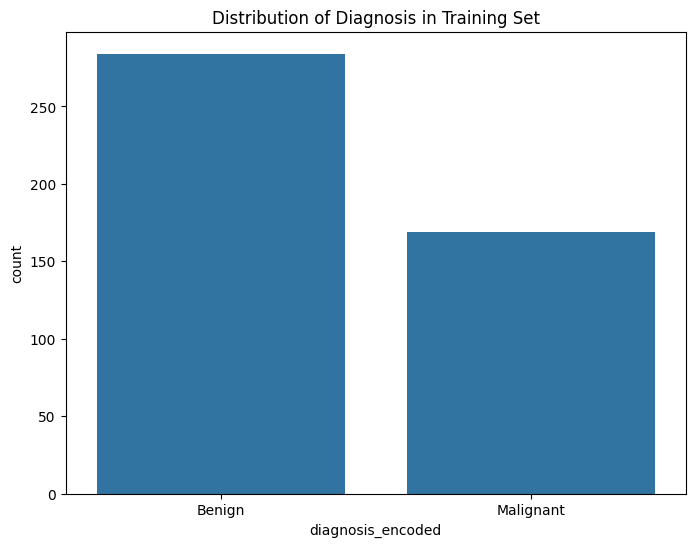

In [ ]:
# Visualising class balance within the training subset to check for possible imbalance
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train.map({0: 'Benign', 1: 'Malignant'}))
plt.title('Distribution of Diagnosis in Training Set')
plt.show()

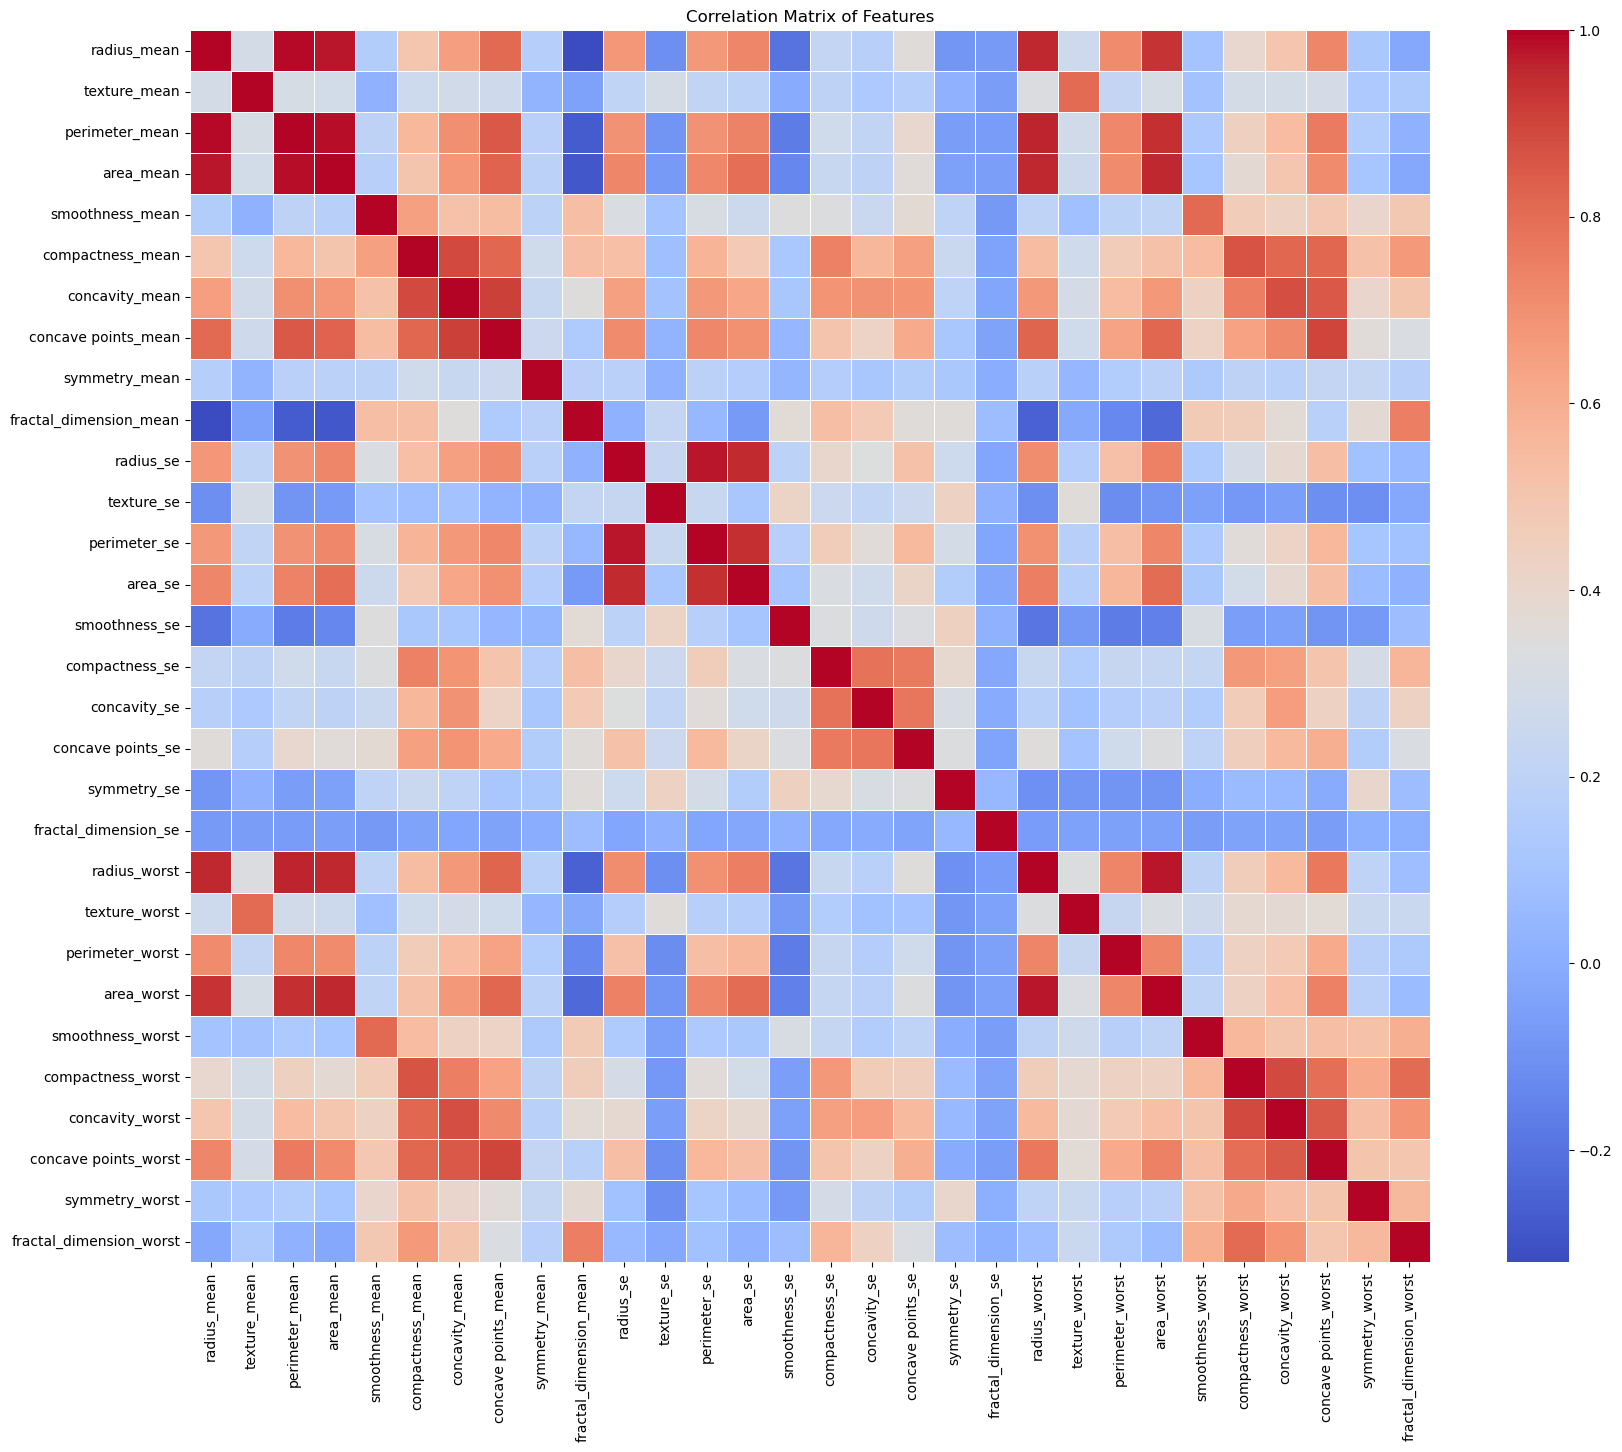

In [ ]:
# Heatmap of correlations

plt.figure(figsize=(20, 16))
correlation_matrix = X_train.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

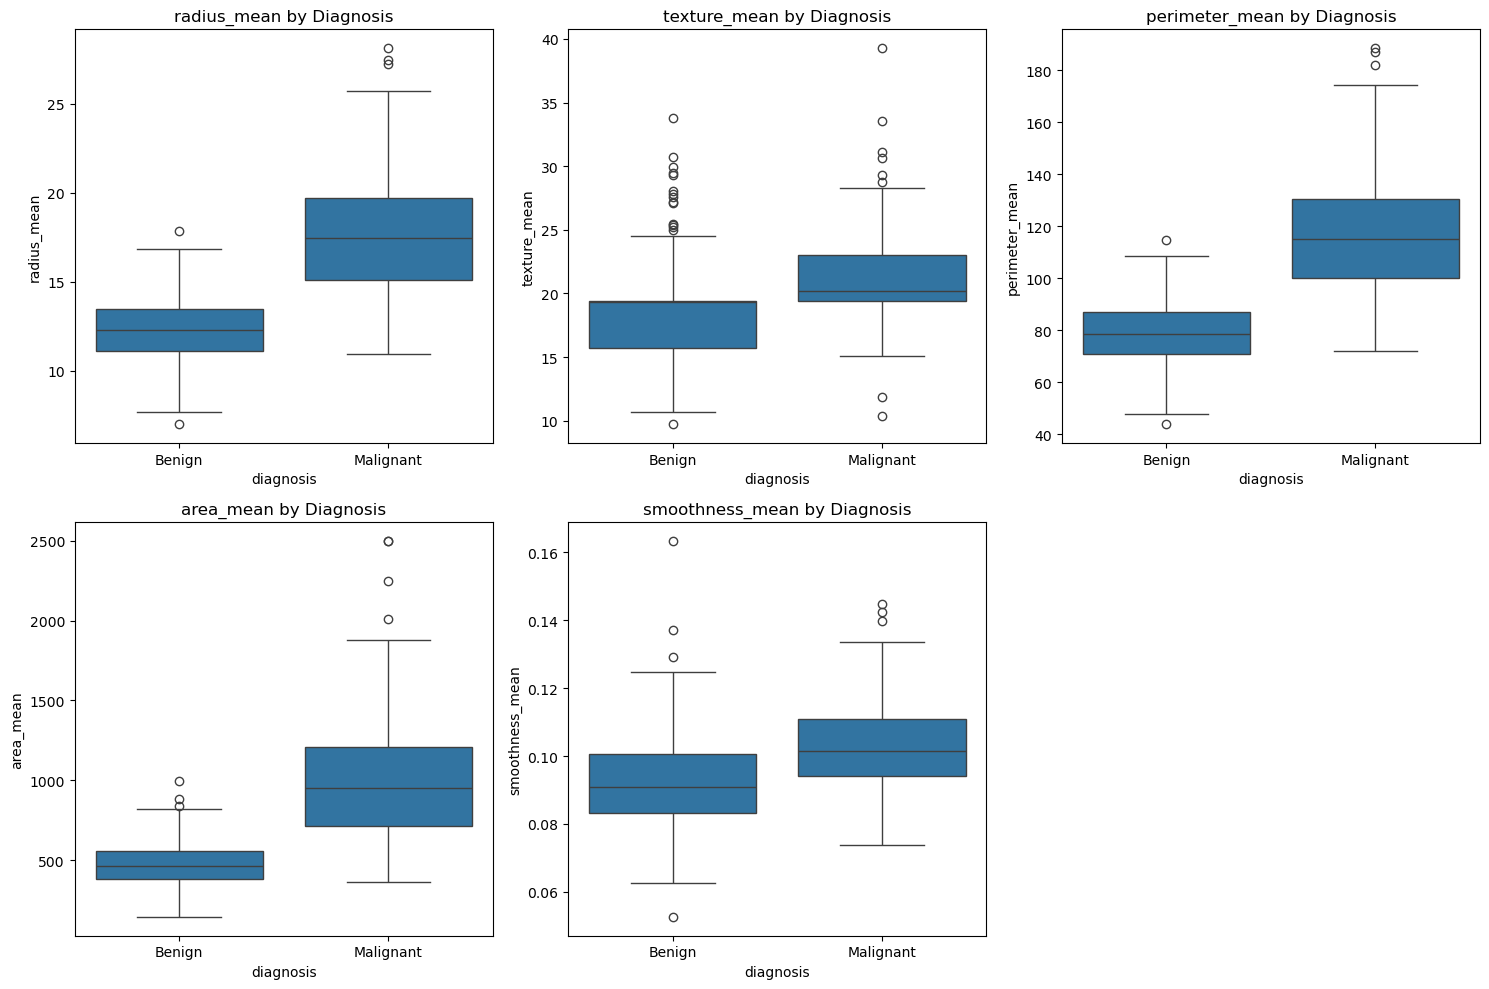

In [8]:
# Box plots for selected features
selected_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean']
df_train = X_train.copy()
df_train['diagnosis'] = y_train.map({0: 'Benign', 1: 'Malignant'})

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=df_train)
    plt.title(f'{feature} by Diagnosis')
plt.tight_layout()
plt.show()

In [9]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

### 1.4 Outlier Detection and Removal

In [ ]:
# Finding outliers with Isolation Forest

isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X_train_scaled)

print(f"Number of outliers detected: {sum(outlier_pred == -1)}")
print(f"Percentage of outliers: {sum(outlier_pred == -1) / len(outlier_pred) * 100:.2f}%")

# Removing outliers
X_train_clean = X_train_scaled[outlier_pred == 1]
y_train_clean = y_train[outlier_pred == 1]

print(f"Training set size after outlier removal: {X_train_clean.shape}")

Number of outliers detected: 42
Percentage of outliers: 9.21%
Training set size after outlier removal: (414, 30)


### 1.5 Feature Engineering

For breast cancer data, we can create features like:
- Mean of all radius measurements
- Mean of all texture measurements
- Ratio features

In [ ]:
# Adding average features for each type of measurement

measurement_types = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                    'compactness', 'concavity', 'concave points', 'symmetry', 'fractal_dimension']

for measurement in measurement_types:
    mean_cols = [col for col in X_train_clean.columns if measurement in col and 'mean' in col]
    if mean_cols:
        X_train_clean[f'{measurement}_overall_mean'] = X_train_clean[mean_cols].mean(axis=1)

        # adding to test set
        test_cols = [col for col in X_test_scaled.columns if measurement in col and 'mean' in col]
        if test_cols:
            X_test_scaled[f'{measurement}_overall_mean'] = X_test_scaled[test_cols].mean(axis=1)

print(f"Training set shape: {X_train_clean.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Training set shape: (414, 40)
Test set shape: (115, 40)


### 1.6 Feature Selection

In [ ]:
# Calculating correlations with target
correlations = X_train_clean.corrwith(y_train_clean).abs().sort_values(ascending=False)
print("Top 10 features by correlation with target:")
print(correlations.head(10))

# Choosing the top k features based on how they relate to each other
k = 20  # Select top 20 features
selected_features = correlations.head(k).index.tolist()
print(f"\nSelected features ({len(selected_features)}): {selected_features}")

# Creating datasets for selected features
X_train_selected = X_train_clean[selected_features]
X_test_selected = X_test_scaled[selected_features]

Top 10 features by correlation with target:
texture_mean            0.172600
texture_overall_mean    0.172600
texture_worst           0.170302
texture_se              0.143693
area_se                 0.107931
area_mean               0.106308
area_overall_mean       0.106308
symmetry_se             0.101587
area_worst              0.098525
concave points_se       0.093624
dtype: float64

Selected features (20): ['texture_mean', 'texture_overall_mean', 'texture_worst', 'texture_se', 'area_se', 'area_mean', 'area_overall_mean', 'symmetry_se', 'area_worst', 'concave points_se', 'perimeter_overall_mean', 'perimeter_mean', 'concavity_se', 'radius_mean', 'radius_overall_mean', 'perimeter_se', 'compactness_se', 'concavity_overall_mean', 'concavity_mean', 'radius_se']


### 1.7 Advanced EDA - Relationship Analysis

In [ ]:
# Making training data with a goal for analysis
train_data = X_train_selected.copy()
train_data['diagnosis'] = y_train_clean

# Summary of statistics by diagnosis
print("Statistical summary by diagnosis:")
summary_stats = train_data.groupby('diagnosis')[selected_features[:5]].describe()
print(summary_stats)

Statistical summary by diagnosis:
          texture_mean                                                    \
                 count      mean       std       min       25%       50%   
diagnosis                                                                  
0.0              190.0 -0.180637  0.894885 -2.545165 -0.761217 -0.005309   
1.0              108.0  0.125245  1.083584 -1.951610 -0.483480 -0.005309   
2.0                3.0  0.880530  1.034058 -0.005309  0.312392  0.630093   

                              texture_overall_mean            ... texture_se  \
                75%       max                count      mean  ...        75%   
diagnosis                                                     ...              
0.0       -0.005309  2.460659                190.0 -0.180637  ...   0.291341   
1.0        0.587414  5.220953                108.0  0.125245  ...   0.527495   
2.0        1.323449  2.016806                  3.0  0.880530  ...   0.475937   

                    area_se 

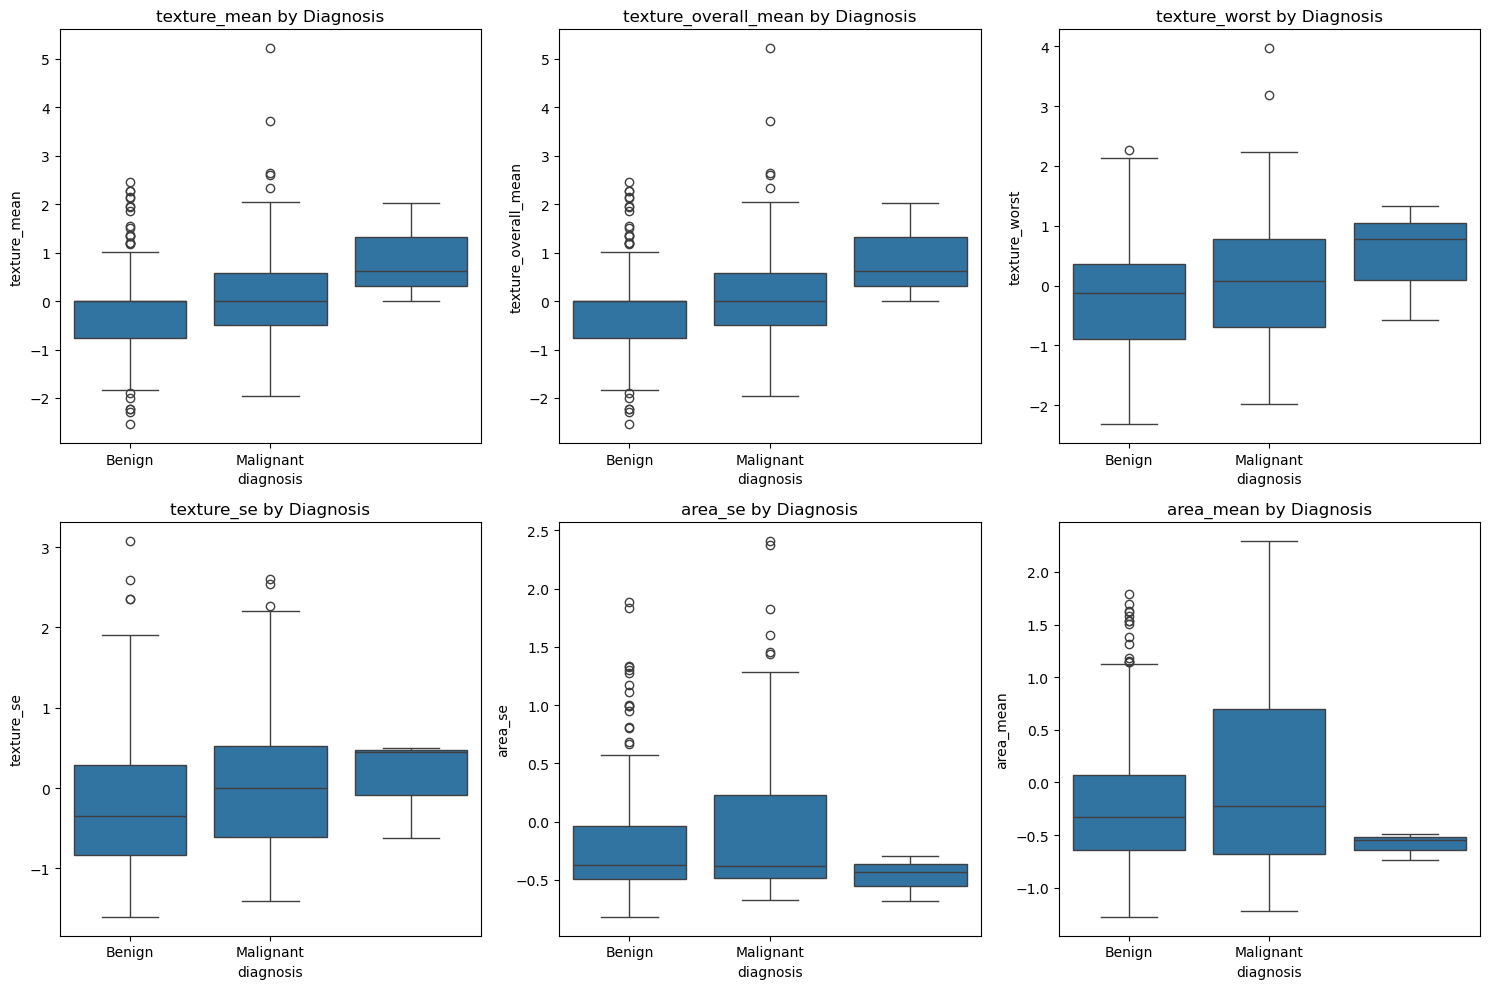

In [ ]:
# Box plots for the most important features by diagnosis

plt.figure(figsize=(15, 10))
for i, feature in enumerate(selected_features[:6]):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=train_data)
    plt.title(f'{feature} by Diagnosis')
    plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.tight_layout()
plt.show()

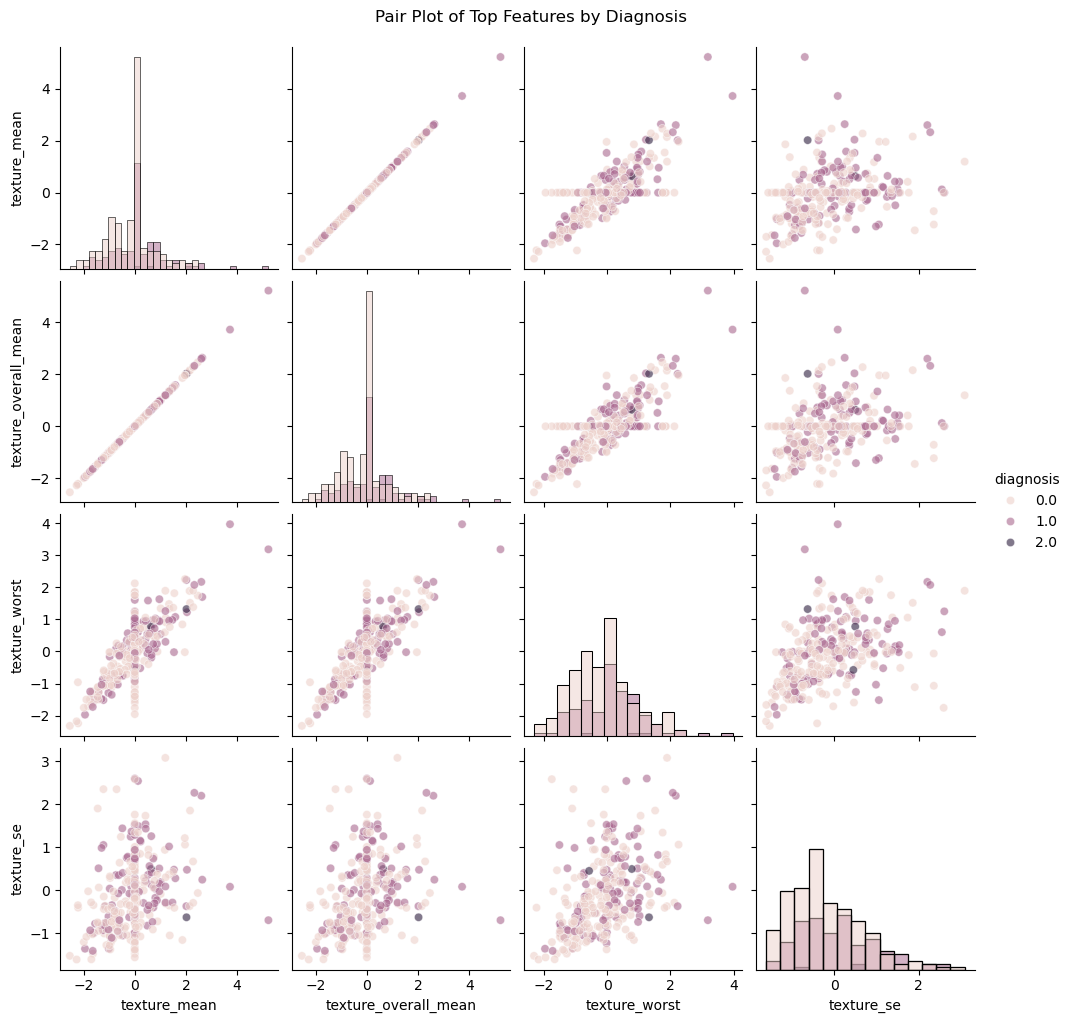

In [16]:
# Pair plot for top features
sns.pairplot(train_data, vars=selected_features[:4], hue='diagnosis',
             plot_kws={'alpha': 0.6}, diag_kind='hist')
plt.suptitle('Pair Plot of Top Features by Diagnosis', y=1.02)
plt.show()

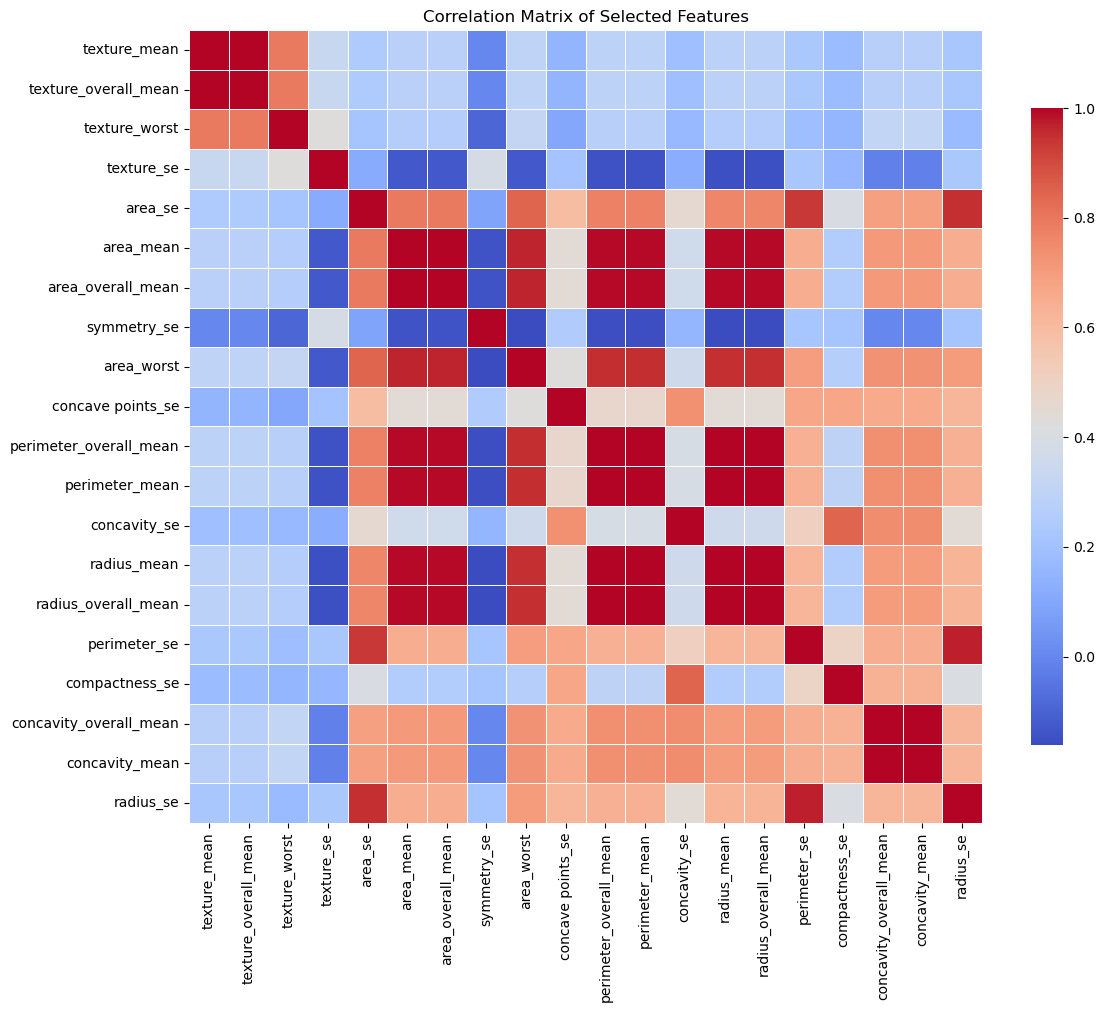

In [17]:
# Correlation heatmap for selected features
plt.figure(figsize=(12, 10))
correlation_matrix = X_train_selected.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Selected Features')
plt.tight_layout()
plt.show()

### 1.8 Summary of Preprocessing and EDA

The original shape of the dataset is (571, 32).

Diagnosis groups:
1. Class 0: 356
2. Class 1: 212
3. Class 2: 3

- Before removing outliers, the training set was (456, 30).
- Set of tests: (115, 30)

- Isolation Forest found 42 outliers (9.21%).
- After removing outliers, the training set is (414, 30)

After feature engineering:

- Shape of the training set: (414, 40)
- The shape of the test set is (115, 40)

- Number of features chosen (based on correlation): 20

Most closely related features to diagnosis:

1. texture_mean (0.1726)
2. texture_overall_mean (0.1726)
3. texture_worst (0.1703)
4. texture_se (0.1437)
5. area_se (0.1079)

## Section 2: Unsupervised Machine Learning Analysis

### 2.1 Dimensionality Reduction with PCA

In [ ]:
# Using PCA to reduce the number of dimensions
pca = PCA()
pca.fit(X_train_selected)

# Explained variance ratio calculation
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio by component:")
for i, ratio in enumerate(explained_variance_ratio[:10]):
    print(f"PC{i+1}: {ratio:.4f}")
    
# Finding the number of parts needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nNumber of components to explain 95% variance: {n_components_95}")

# Applying PCA with optimal number of components
pca_optimal = PCA(n_components=n_components_95)
X_train_pca = pca_optimal.fit_transform(X_train_selected)
X_test_pca = pca_optimal.transform(X_test_selected)

print(f"Reduced training set shape: {X_train_pca.shape}")
print(f"Reduced test set shape: {X_test_pca.shape}")

Explained variance ratio by component:
PC1: 0.5315
PC2: 0.1850
PC3: 0.1175
PC4: 0.0581
PC5: 0.0326
PC6: 0.0264
PC7: 0.0186
PC8: 0.0116
PC9: 0.0105
PC10: 0.0034

Number of components to explain 95% variance: 6
Reduced training set shape: (414, 6)
Reduced test set shape: (115, 6)


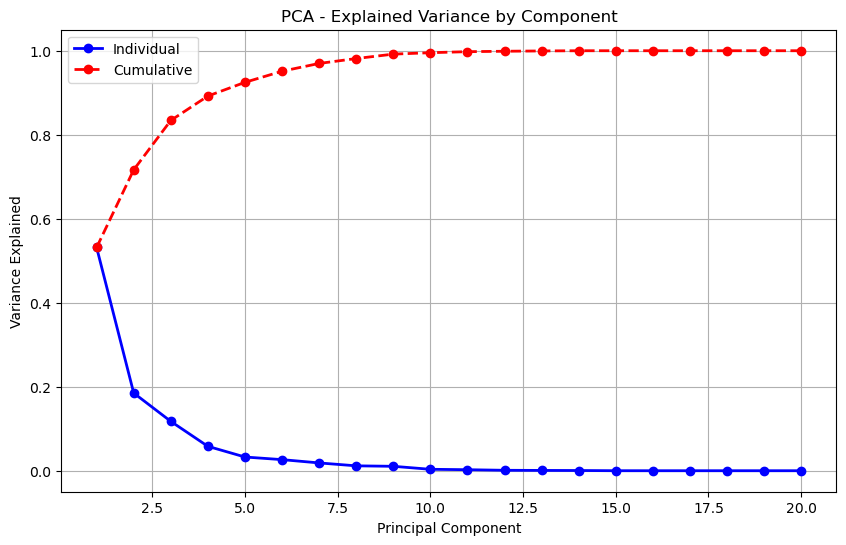

In [ ]:
# visualization OF PCA 
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro--', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('PCA - Explained Variance by Component')
plt.legend(['Individual', 'Cumulative'])
plt.grid(True)
plt.show()

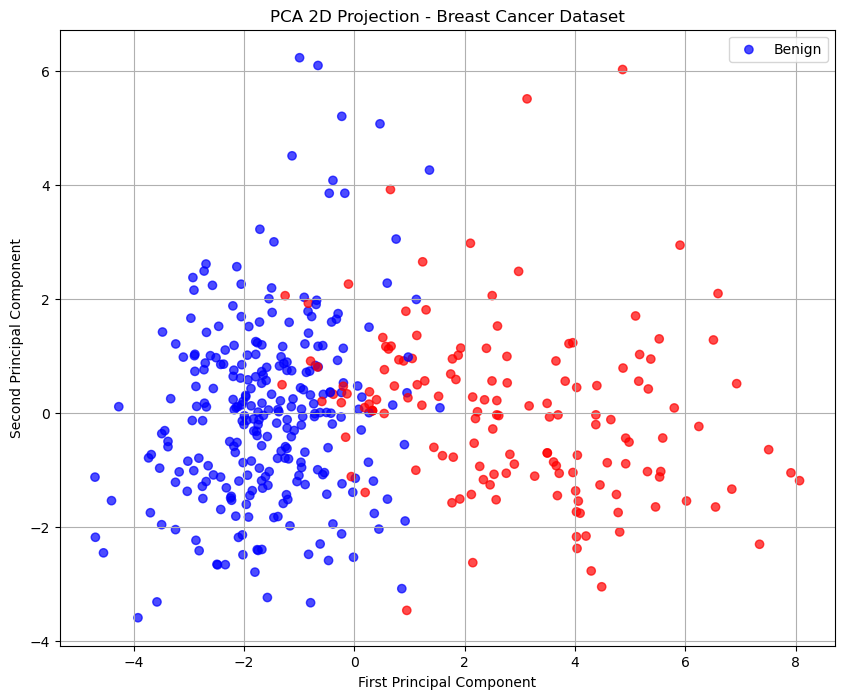

In [ ]:
# 2D PCA scatter plot with colours based on diagnosis
pca_2d = PCA(n_components=2)
X_train_pca_2d = pca_2d.fit_transform(X_train_selected)

plt.figure(figsize=(10, 8))
colors = ['blue' if label == 0 else 'red' for label in y_train_clean]
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=colors, alpha=0.7)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA 2D Projection - Breast Cancer Dataset')
plt.legend(['Benign', 'Malignant'])
plt.grid(True)
plt.show()

### 2.2 Clustering Analysis

#### 2.2.1 K-Means Clustering

In [ ]:
# K-Means clustering on data that has been reduced by PCA
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_train_pca)

print(f"K-means cluster centers shape: {kmeans.cluster_centers_.shape}")
print(f"K-means inertia: {kmeans.inertia_:.2f}")

# Checking the quality of clustering
silhouette_avg = silhouette_score(X_train_pca, kmeans_labels)
print(f"Silhouette score: {silhouette_avg:.4f}")

K-means cluster centers shape: (2, 6)
K-means inertia: 3031.11
Silhouette score: 0.4183


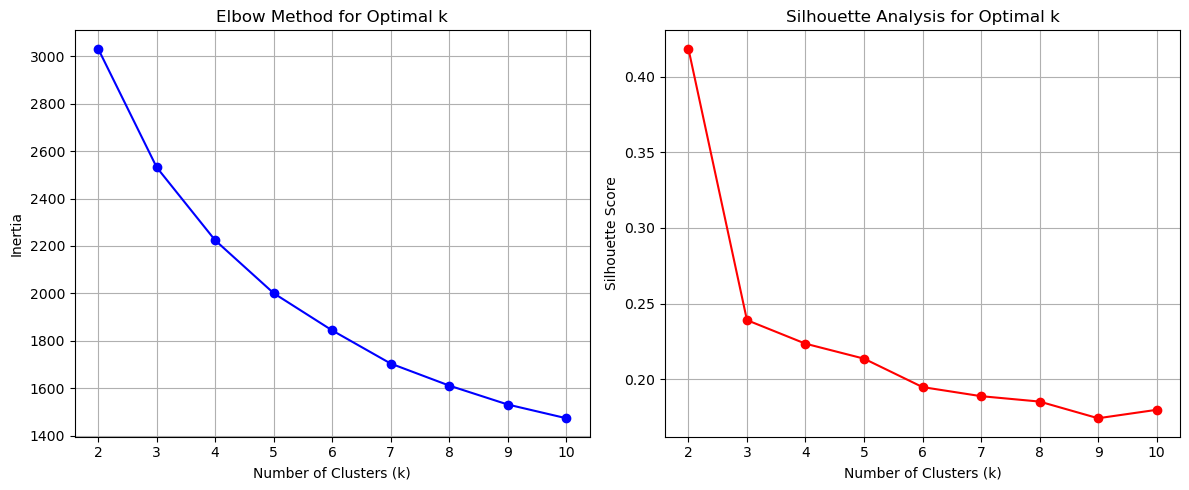

Optimal number of clusters based on silhouette score: 2


In [ ]:
# Using the elbow method and silhouette analysis to find the best number of clusters
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans_temp.fit(X_train_pca)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(X_train_pca, kmeans_temp.labels_))

# Plotting elbow curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis for Optimal k')
plt.grid(True)

plt.tight_layout()
plt.show()

# Finding best k based on silhouette score
best_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {best_k}")

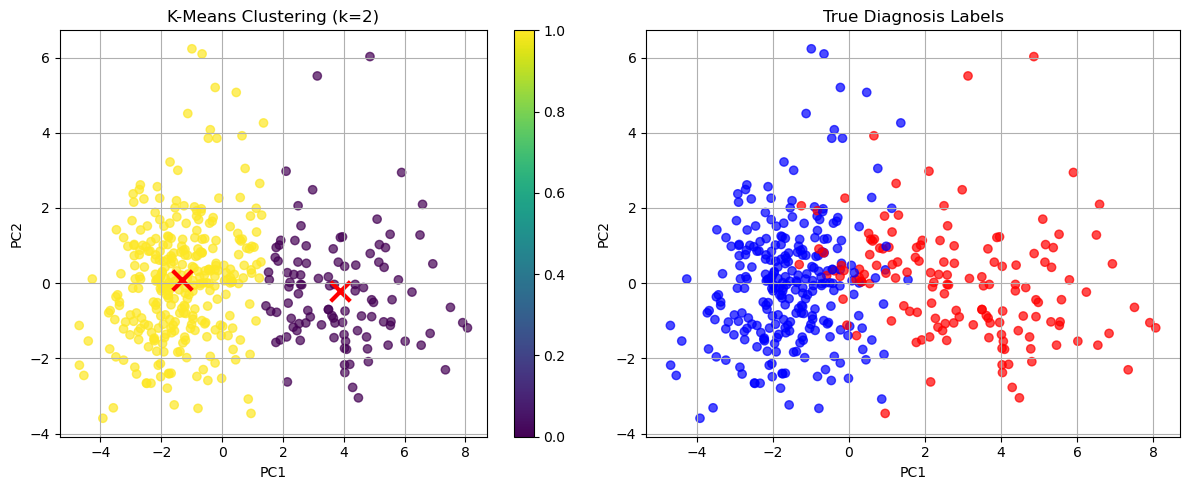

In [ ]:
# Visualisation of K-means clustering
kmeans_optimal = KMeans(n_clusters=best_k, n_init=10, random_state=42)
kmeans_optimal_labels = kmeans_optimal.fit_predict(X_train_pca_2d)

plt.figure(figsize=(12, 5))

# Plotting K-means clusters
plt.subplot(1, 2, 1)
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=kmeans_optimal_labels, cmap='viridis', alpha=0.7)
plt.scatter(kmeans_optimal.cluster_centers_[:, 0], kmeans_optimal.cluster_centers_[:, 1],
           c='red', marker='x', s=200, linewidth=3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means Clustering (k={best_k})')
plt.colorbar()
plt.grid(True)

# Comparing with true labels
plt.subplot(1, 2, 2)
colors = ['blue' if label == 0 else 'red' for label in y_train_clean]
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=colors, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('True Diagnosis Labels')
plt.grid(True)

plt.tight_layout()
plt.show()

#### 2.2.2 DBSCAN Clustering

In [ ]:
# Clustering with DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_train_pca_2d)

print(f"DBSCAN found {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters")
print(f"Number of noise points: {list(dbscan_labels).count(-1)}")

# Getting the silhouette score
if len(set(dbscan_labels)) > 1:
    mask = dbscan_labels != -1
    if sum(mask) > 1:
        dbscan_silhouette = silhouette_score(X_train_pca_2d[mask], dbscan_labels[mask])
        print(f"DBSCAN silhouette score: {dbscan_silhouette:.4f}")
    else:
        print("Not enough non-noise points for silhouette analysis")
else:
    print("DBSCAN found only noise")

DBSCAN found 5 clusters
Number of noise points: 81
DBSCAN silhouette score: -0.0937


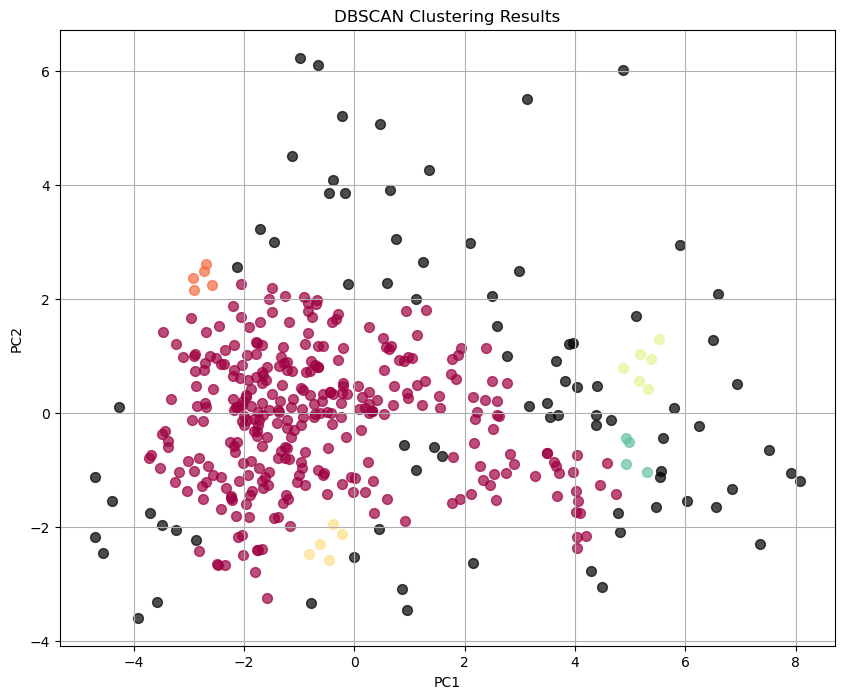

In [ ]:
# DBSCAN visualization
plt.figure(figsize=(10, 8))

# Creating color map for clusters
unique_labels = set(dbscan_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black' # for noise

    class_member_mask = (dbscan_labels == k)

    xy = X_train_pca_2d[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], alpha=0.7, s=50)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering Results')
plt.grid(True)
plt.show()

#### 2.2.3 Hierarchical Clustering

In [26]:
hierarchical = AgglomerativeClustering(n_clusters=best_k)
hierarchical_labels = hierarchical.fit_predict(X_train_pca_2d)

hierarchical_silhouette = silhouette_score(X_train_pca_2d, hierarchical_labels)
print(f"Hierarchical clustering silhouette score: {hierarchical_silhouette:.4f}")

Hierarchical clustering silhouette score: 0.5148


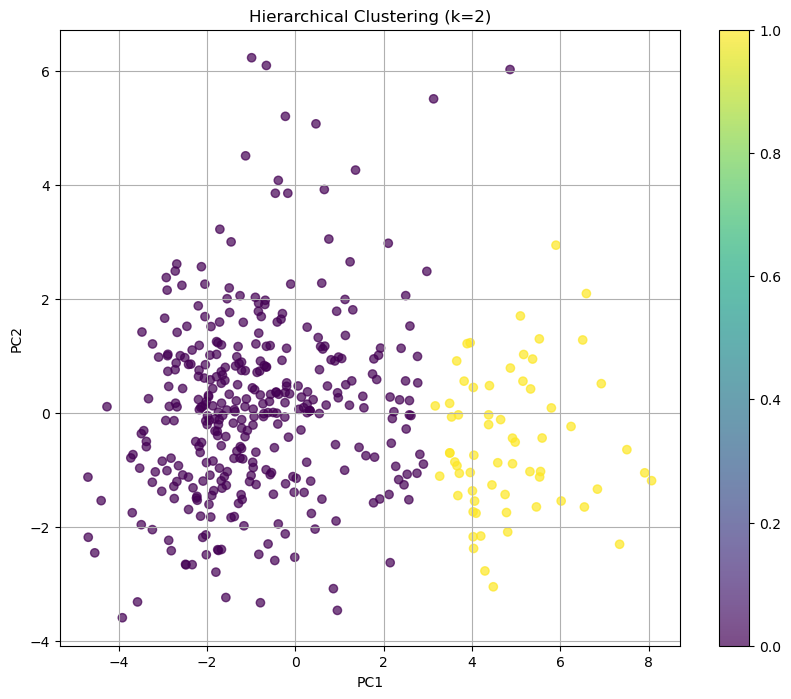

In [ ]:
# visualizING Hierarchical clustering 
plt.figure(figsize=(10, 8))
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Hierarchical Clustering (k={best_k})')
plt.colorbar()
plt.grid(True)
plt.show()

### 2.3 Clustering Evaluation and Comparison

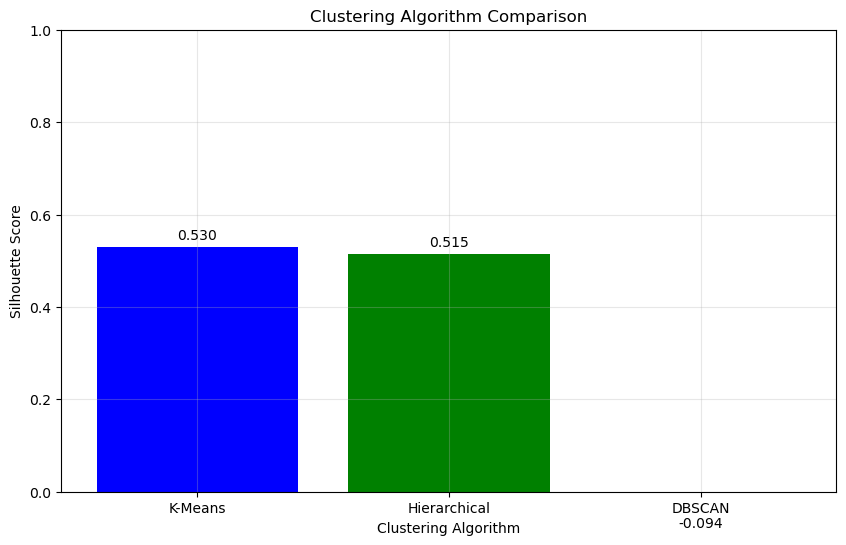

In [ ]:
# Looking at different clustering algorithms
algorithms = ['K-Means', 'Hierarchical']
silhouette_scores_comparison = [silhouette_score(X_train_pca_2d, kmeans_optimal_labels),
                               hierarchical_silhouette]

# For DBSCAN
if len(set(dbscan_labels)) > 1 and sum(dbscan_labels != -1) > 1:
    algorithms.append('DBSCAN')
    silhouette_scores_comparison.append(dbscan_silhouette)

plt.figure(figsize=(10, 6))
bars = plt.bar(algorithms, silhouette_scores_comparison,
               color=['blue', 'green', 'red'][:len(algorithms)])
plt.xlabel('Clustering Algorithm')
plt.ylabel('Silhouette Score')
plt.title('Clustering Algorithm Comparison')
plt.ylim(0, 1)

for bar, score in zip(bars, silhouette_scores_comparison):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.show()

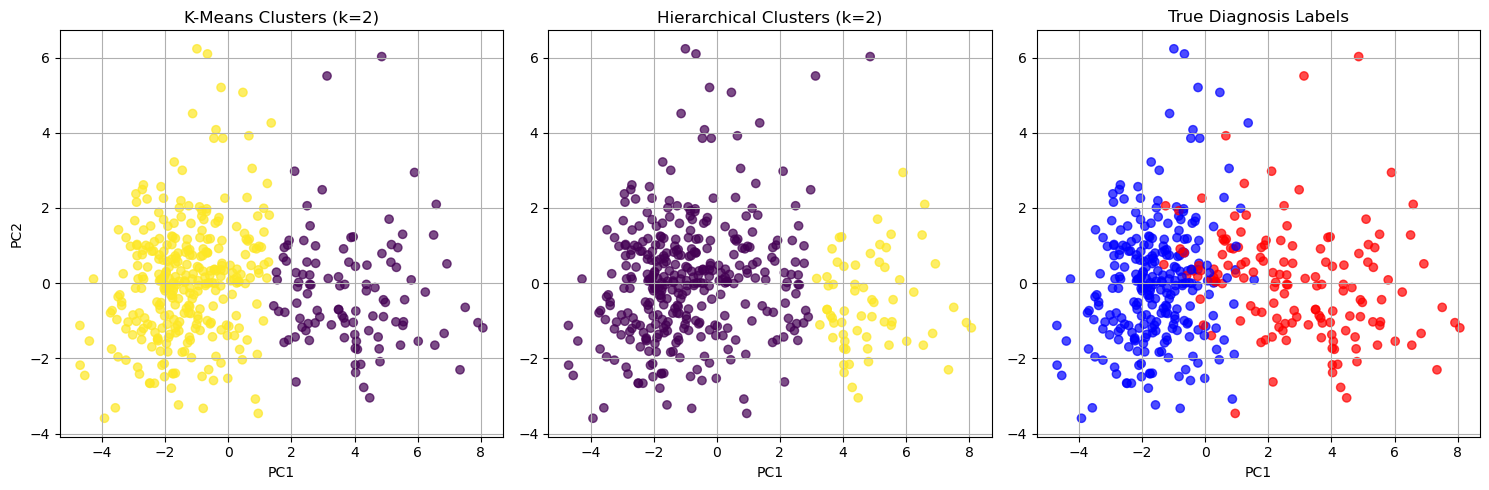

In [ ]:
# A visual comparison of clustering results with real labels
plt.figure(figsize=(15, 5))

# K-means vs True labels
plt.subplot(1, 3, 1)
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1],
            c=kmeans_optimal_labels, cmap='viridis', alpha=0.7)
plt.title(f'K-Means Clusters (k={best_k})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)

# Hierarchical vs True labels
plt.subplot(1, 3, 2)
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1],
            c=hierarchical_labels, cmap='viridis', alpha=0.7)
plt.title(f'Hierarchical Clusters (k={best_k})')
plt.xlabel('PC1')
plt.grid(True)

# True labels for comparison
plt.subplot(1, 3, 3)
colors = ['blue' if label == 0 else 'red' for label in y_train_clean]
plt.scatter(X_train_pca_2d[:, 0], X_train_pca_2d[:, 1], c=colors, alpha=0.7)
plt.title('True Diagnosis Labels')
plt.xlabel('PC1')
plt.grid(True)

plt.tight_layout()
plt.show()

### 2.4 Critical Assessment of Unsupervised Learning Results

Results of PCA:
- The original feature space had 20 dimensions.
- Cut down to 6 parts that explain 95% of the variance
- The first two PCs explain 71.6% of the variance.

Results of Clustering:
- The best number of K-Means clusters is 2.
- K-Means silhouette score: 0.5298
- The silhouette score for hierarchical clustering is 0.5148.
- There are 5 DBSCAN clusters.
- 81 noise points in DBSCAN
- DBSCAN silhouette score: -0.0937


Results and Discussion:
- PCA worked well to lower dimensionality while keeping 95.1% of the variance.
- Clustering algorithms show a fair amount of separation between benign and malignant cases.
- K-Means (k=2) gave the best quality of internal clustering (highest silhouette)
- Hierarchical clustering also worked well and backs up the two-group structure.
- DBSCAN didn't work well and thought that many points were noise or outliers.

## Section 3: Supervised Machine Learning Analysis

### 3.1 Classification Algorithms for Breast Cancer Prediction

In [ ]:
# Defining classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Training and testing each model with cross-validation
model_results = {}
results_data = []

for name, model in models.items():

# Scores for cross-validation
    cv_scores = cross_val_score(model, X_train_selected, y_train_clean, cv=5, scoring='accuracy')

    # Training on the whole training set and making predictions on the test set
    model.fit(X_train_selected, y_train_clean)
    y_pred = model.predict(X_test_selected)

    # Calculating metrics
    accuracy = accuracy_score(y_test, y_pred)

    model_results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_accuracy': accuracy,
        'model': model,
        'predictions': y_pred
    }
# Save the results for the DataFrame
    results_data.append({
        'Model': name,
        'CV Mean Accuracy': f"{cv_scores.mean():.4f}",
        'CV Std Dev': f"{cv_scores.std():.4f}",
        'CV Range': f"±{cv_scores.std() * 2:.4f}",
        'Test Accuracy': f"{accuracy:.4f}"
    })
    
# Showing results in a pandas DataFrame
results_df = pd.DataFrame(results_data)
display(results_df)

,Model,CV Mean Accuracy,CV Std Dev,CV Range,Test Accuracy
0,Logistic Regression,0.9710,0.0096,±0.0192,0.9304
1,Decision Tree,0.9179,0.0091,±0.0182,0.9217
2,Random Forest,0.9396,0.0252,±0.0504,0.9565
3,SVM,0.9734,0.0160,±0.0321,0.9478
4,K-Nearest Neighbors,0.9396,0.0215,±0.0430,0.9043


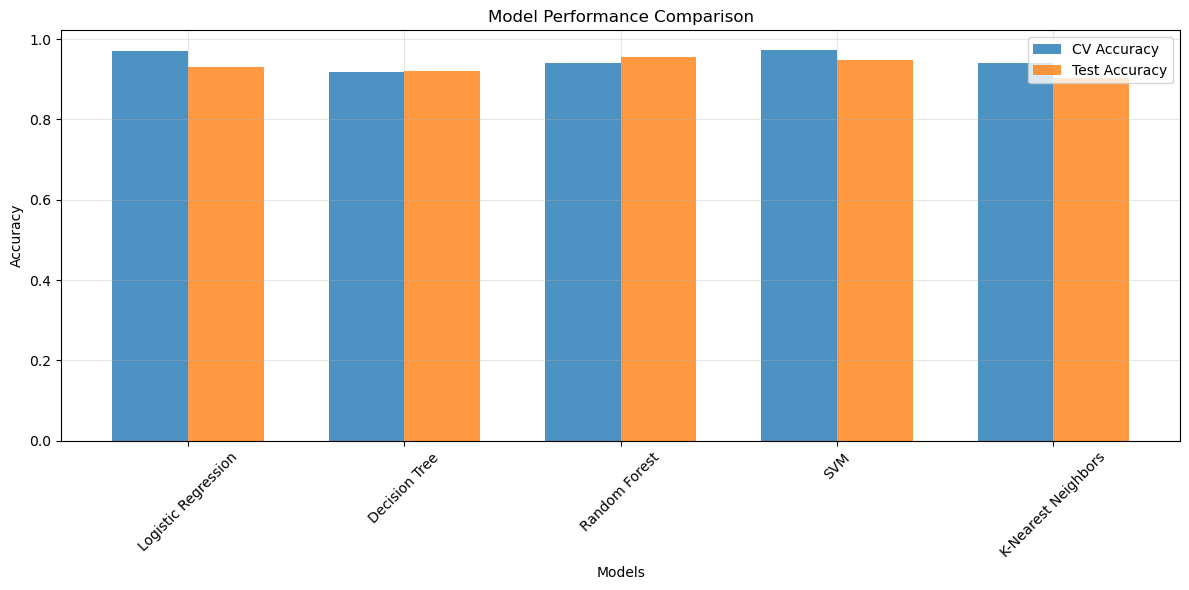

In [ ]:
# Comparing how well models work
model_names = list(model_results.keys())
cv_scores = [model_results[name]['cv_mean'] for name in model_names]
test_scores = [model_results[name]['test_accuracy'] for name in model_names]

plt.figure(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.35

plt.bar(x - width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
plt.bar(x + width/2, test_scores, width, label='Test Accuracy', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Detailed Model Evaluation

In [ ]:
# Choosing the model that works best for in-depth analysis
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['test_accuracy'])
best_model = model_results[best_model_name]['model']
best_predictions = model_results[best_model_name]['predictions']

# A DataFrame with a detailed classification report
precision, recall, f1, support = precision_recall_fscore_support(y_test, best_predictions)

classification_df = pd.DataFrame({
    'Class': ['Benign', 'Malignant'],
    'Precision': [f"{p:.4f}" for p in precision],
    'Recall': [f"{r:.4f}" for r in recall],
    'F1-Score': [f"{f:.4f}" for f in f1],
    'Support': support
})

print("\nClassification Report:")
display(classification_df)

# Confusion matrix
cm = confusion_matrix(y_test, best_predictions)
cm_df = pd.DataFrame(cm,
                     columns=['Predicted Benign', 'Predicted Malignant'],
                     index=['Actual Benign', 'Actual Malignant'])
print("\nConfusion Matrix:")
display(cm_df)


Classification Report:


,Class,Precision,Recall,F1-Score,Support
0,Benign,0.9467,0.9861,0.9660,72
1,Malignant,0.9750,0.9070,0.9398,43



Confusion Matrix:


,Predicted Benign,Predicted Malignant
Actual Benign,71,1
Actual Malignant,4,39


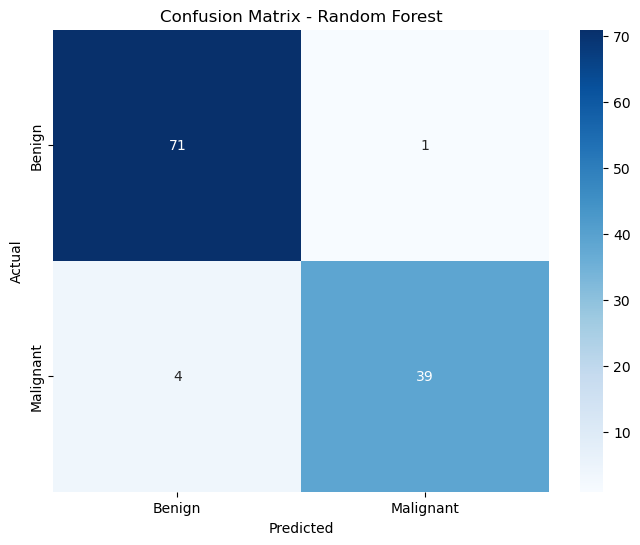

In [ ]:
# Showing confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

### 3.3 Hyperparameter Tuning

In [ ]:
# Using GridSearchCV to tune hyperparameters for the best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
elif best_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [1, 0.1, 0.01, 0.001],
        'kernel': ['rbf', 'linear']
    }
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    }
elif best_model_name == 'K-Nearest Neighbors':
    param_grid = {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
else:  
    param_grid = {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'criterion': ['gini', 'entropy']
    }

# Doing a grid search
grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_clean)

# Showing the best parameters
best_params_df = pd.DataFrame([grid_search.best_params_]).T
best_params_df.columns = ['Best Value']
best_params_df.index.name = 'Parameter'
print("\nBest Parameters:")
display(best_params_df)

# Checking the tuned model against the test set
tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test_selected)
tuned_accuracy = accuracy_score(y_test, tuned_predictions)

# Showing a comparison of performance
performance_comparison = pd.DataFrame({
    'Metric': ['Best CV Score', 'Original Test Accuracy', 'Tuned Test Accuracy', 'Improvement'],
    'Value': [
        f"{grid_search.best_score_:.4f}",
        f"{model_results[best_model_name]['test_accuracy']:.4f}",
        f"{tuned_accuracy:.4f}",
        f"{tuned_accuracy - model_results[best_model_name]['test_accuracy']:.4f}"
    ]
})
print("\nPerformance Comparison:")
display(performance_comparison)


Best Parameters:


,Best Value
Parameter,
max_depth,None
min_samples_leaf,2
min_samples_split,5
n_estimators,50



Performance Comparison:


,Metric,Value
0,Best CV Score,0.9421
1,Original Test Accuracy,0.9565
2,Tuned Test Accuracy,0.9739
3,Improvement,0.0174


### 3.4 Feature Importance Analysis

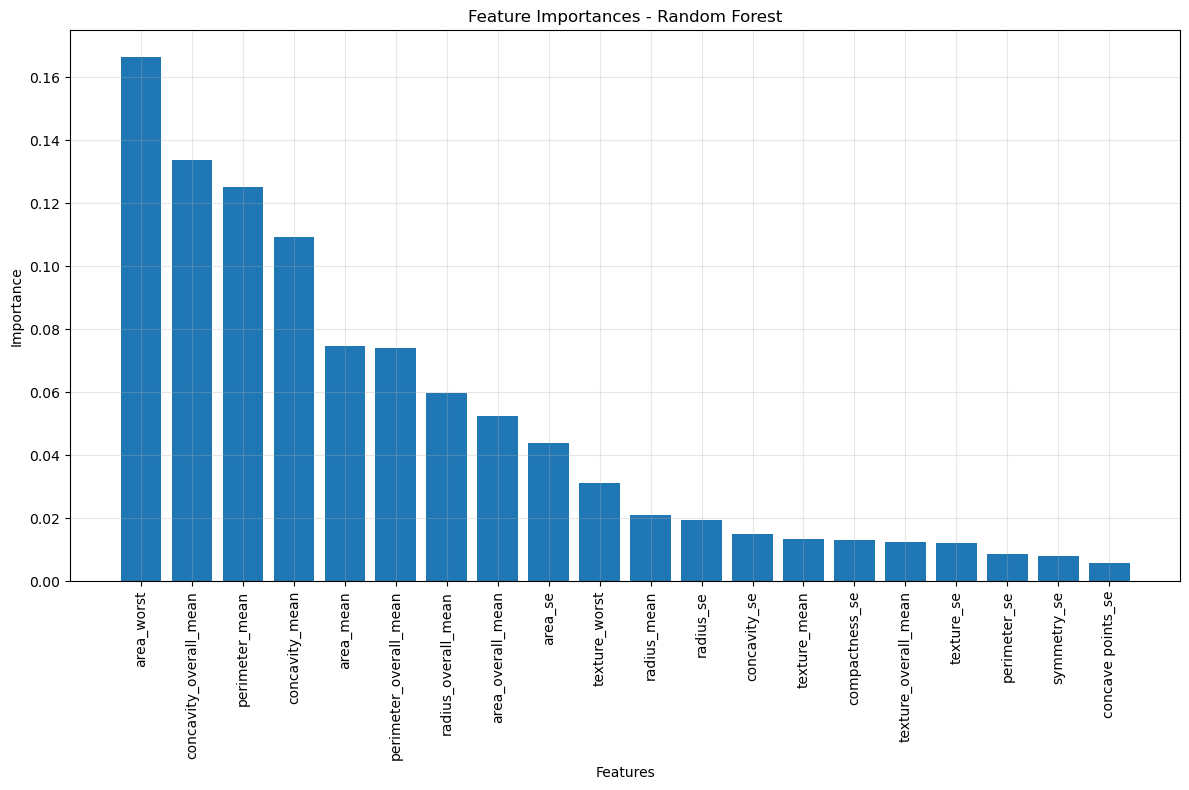


Top 10 Most Important Features:


,Rank,Feature,Importance,Importance (%)
0,1,area_worst,0.1666,16.66%
1,2,concavity_overall_mean,0.1336,13.36%
2,3,perimeter_mean,0.1253,12.53%
3,4,concavity_mean,0.1093,10.93%
4,5,area_mean,0.0747,7.47%
5,6,perimeter_overall_mean,0.0741,7.41%
6,7,radius_overall_mean,0.0597,5.97%
7,8,area_overall_mean,0.0526,5.26%
8,9,area_se,0.0440,4.40%
9,10,texture_worst,0.0313,3.13%


In [ ]:
# How important features are for tree-based models

if hasattr(tuned_model, 'feature_importances_'):
    feature_importance = tuned_model.feature_importances_

    # Sort features by how important they are
    indices = np.argsort(feature_importance)[::-1]

    plt.figure(figsize=(12, 8))
    plt.title(f'Feature Importances - {best_model_name}')
    plt.bar(range(len(feature_importance)), feature_importance[indices], align='center')
    plt.xticks(range(len(feature_importance)), [selected_features[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Showing the ten most important features
    top_n = min(10, len(feature_importance))
    importance_df = pd.DataFrame({
        'Rank': range(1, top_n + 1),
        'Feature': [selected_features[indices[i]] for i in range(top_n)],
        'Importance': [f"{feature_importance[indices[i]]:.4f}" for i in range(top_n)],
        'Importance (%)': [f"{feature_importance[indices[i]] * 100:.2f}%" for i in range(top_n)]
    })
    print("\nTop 10 Most Important Features:")
    display(importance_df)

elif hasattr(tuned_model, 'coef_'):
  # showing how big the coefficients are for linear models

    coefficients = np.abs(tuned_model.coef_[0])
    indices = np.argsort(coefficients)[::-1]

    plt.figure(figsize=(12, 8))
    plt.title(f'Feature Coefficients - {best_model_name}')
    plt.bar(range(len(coefficients)), coefficients[indices], align='center')
    plt.xticks(range(len(coefficients)), [selected_features[i] for i in indices], rotation=90)
    plt.xlabel('Features')
    plt.ylabel('Coefficient Magnitude')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

  # Showing the 10 most important features
    top_n = min(10, len(coefficients))
    coef_df = pd.DataFrame({
        'Rank': range(1, top_n + 1),
        'Feature': [selected_features[indices[i]] for i in range(top_n)],
        'Coefficient Magnitude': [f"{coefficients[indices[i]]:.4f}" for i in range(top_n)]
    })
    print("\nTop 10 Most Important Features (by coefficient magnitude):")
    display(coef_df)

### 3.5 Model Robustness and Validation

In [ ]:
# Additional cross-validation to check model stability
cv_scores_detailed = cross_val_score(tuned_model, X_train_selected, y_train_clean, cv=10, scoring='accuracy')
print(f"\nDetailed Cross-Validation Results for {best_model_name}:")
print(f"CV Scores: {cv_scores_detailed}")
print(f"Mean CV Score: {cv_scores_detailed.mean():.4f}")
print(f"CV Score Std: {cv_scores_detailed.std():.4f}")
print(f"Test Score: {tuned_accuracy:.4f}")

# Checking for overfitting by comparing training and CV scores
tuned_model.fit(X_train_selected, y_train_clean)
train_accuracy = accuracy_score(y_train_clean, tuned_model.predict(X_train_selected))
print(f"Training Accuracy: {train_accuracy:.4f}")

overfitting_indicator = train_accuracy - cv_scores_detailed.mean()
print(f"Overfitting indicator (Train - CV): {overfitting_indicator:.4f}")
if overfitting_indicator > 0.1:
    print("Warning: Possible overfitting detected")
else:
    print("Model shows good generalization")


Detailed Cross-Validation Results for Random Forest:
CV Scores: [0.92857143 1.         0.95238095 0.95238095 0.92682927 0.97560976
 0.90243902 0.92682927 0.97560976 0.90243902]
Mean CV Score: 0.9443
CV Score Std: 0.0309
Test Score: 0.9739
Training Accuracy: 0.9928
Overfitting indicator (Train - CV): 0.0484
Model shows good generalization


### 3.6 Critical Assessment of Supervised Learning Results

The best model is Random Forest.
- Accuracy of the original test: 0.9565
- Adjusted test accuracy: 0.9739
- The average score for cross-validation (10-fold) is 0.9443.
- The best CV score (GridSearch) is 0.9421.

Comparison of models:
- Logistic Regression: CV=0.9710, Test=0.9304
- Decision Tree: CV=0.9179 and Test=0.9217
- Random Forest: CV=0.9396, Test=0.9565
- Support Vector Machine: CV=0.9734, Test=0.9478
- K-Nearest Neighbours: CV=0.9396, Test=0.9043

Results and Discussion:
- After tuning, Random Forest had the best test accuracy (0.9739)
- The model generalises well (Train = 0.9928, CV = 0.9443, small overfitting gap = 0.0484)
- The confusion matrix shows that the classification works very well (only 5 misclassifications).
- The most important predictors are area_worst, concavity_overall_mean, perimeter_mean, and concavity_mean.
- The tuned Random Forest model is a very accurate way to tell if someone has breast cancer.

## Section 4: Conclusions



### 4.1 Summary

Data Preprocessing and EDA

- There were 571 observations and 32 variables in the dataset. One of these was the diagnosis variable, which had three groups: 356, 212, and 3 cases.
- The missing values were found and filled in, so there were no missing values after preprocessing.
- The data was divided into two sets: one for training (456, 30) and one for testing (115, 30).
- Isolation Forest found 42 outliers (9.21%), which cut the training set down to (414, 30).
- Feature engineering added 40 new features to the dataset, and correlation-based feature selection kept the 20 that were most useful.
- The features that were most closely related to diagnosis were texture_mean (0.1726), texture_overall_mean (0.1726), texture_worst (0.1703), texture_se (0.1437), and area_se (0.1079).
- Correlation heatmaps and boxplots indicated significant associations among size-related metrics (radius, perimeter, area), revealing markedly distinct distributions between benign and malignant instances.


Analysis of Unsupervised Learning

1. PCA cut the 20 chosen features down to 6 main components, which made up about 95% of the total variation. The first two parts made up 71.6% of the difference.
2. K-Means (k=2) did the best job of grouping, with a silhouette score of 0.5298, which was the same as the two most common diagnosis groups.
3. When hierarchical clustering was used, the structure was similar, and the silhouette score was 0.5148.
4. DBSCAN found 81 noise spots and 5 clusters. The negative silhouette score (-0.0937) means that the clusters weren't set up right based on the settings that were used.
5. Overall, clustering showed a moderate amount of natural separation that was in line with benign and malignant groupings.



Analysis of Supervised Learning

1. I evaluated five models: Logistic Regression, Decision Tree, Random Forest, SVM, and KNN.
2. After tuning, the Random Forest model worked the best:
     * The original test accuracy was 0.9565.
     * The accuracy of the tuned test was 0.9739.
     * Average 10-fold CV score: 0.9443
     * GridSearch CV score: 0.9421
3. The confusion matrix only showed 5 wrong classifications, which means it can make strong predictions.
4. The analysis of feature importance showed that area_worst, concavity_overall_mean, perimeter_mean, and concavity_mean were the most important predictors.
5. The small difference between training (0.9928) and CV performance (0.0484) suggests that the model generalises well and doesn't overfit too much.


### 4.2 Key Findings

Strengths of the Analysis

1. End-to-End Pipeline: It included preprocessing, reducing the number of dimensions, clustering, classifying, and testing.
2. Strong Validation: Used stratified splitting and 10-fold cross-validation to get a good idea of how well the model would work.
3. Feature Engineering and Selection: Made things easier to understand and reduced the number of dimensions.
4. Algorithm Comparison: Looked at several models to see why Random Forest was chosen.
5. Strong Predictive Accuracy: The test accuracy was very high (97.39%), and there were very few mistakes.


Limitations of the Analysis

1. Small Minority Class: There are only three samples in Class 2, which makes it hard for that group to learn reliably.
2. Moderate Class Imbalance: The distribution of classes is still biased toward benign cases.
3. Dataset Scope: The results come from just one dataset and may need to be checked by someone else.
4. Model Interpretability: Random Forest is a powerful model, but it is harder to understand than linear models.


### 4.3 Ethical Implications

1. Data Privacy: Medical datasets require strict confidentiality, anonymization, and secure storage.
2. Bias & Representation: Limited representation of minority cases may affect fairness.
3. Clinical Use: The model should support—not replace—clinical expertise.
4. Transparency: Use SHAP or LIME to help people understand your predictions.


1. Data Privacy: Medical datasets need to be kept private, anonymous, and safe.
2. Bias and Representation: Not enough representation of minority cases could make things less fair.
3. Clinical Use: The model should help, not replace, the knowledge of doctors.
4. Be clear: Use SHAP or LIME to help people understand what you think will happen.

### 4.4 Future Work

1. External validation: Use different sets of data to see if the model works in other situations.
2. Dealing with Class Imbalance: Look into resampling methods to better model classes that don't happen very often.
3. Advanced Models: Look into techniques like ensemble stacking or deep learning.
4. Use SHAP or LIME to make predictions easier to understand.




## References

Cortes, C. and Vapnik, V. (1995) ‘Support-Vector Networks’, Machine Learning, 20(3), pp. 273–297. https://doi.org/10.1007/BF00994018

GeeksforGeeks (2024) Understanding Feature Importance and Visualization of Tree Models. Available at: https://www.geeksforgeeks.org/machine-learning/understanding-feature-importance-and-visualization-of-tree-models/
(Accessed: 17 January 2026).

Géron, A. (2022) Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow. 3rd edn. Sebastopol, CA: O’Reilly Media.

Liu, F.T., Ting, K.M. and Zhou, Z.-H. (2008) ‘Isolation Forest’, in Proceedings of the 2008 Eighth IEEE International Conference on Data Mining (ICDM). Pisa, Italy: IEEE, pp. 413–422. https://doi.org/10.1109/ICDM.2008.17

OpenAI (2026) ChatGPT (GPT-4) [Large language model]. Available at: https://chat.openai.com/
(Accessed: 22 February 2026). Prompt: “Solve the NameError: X_train_pca_2d is not defined in my K-Means and DBSCAN clustering code. Ensure the PCA transformation is correctly applied before clustering.”





